# Tratado 3 — Evaluación conjunta YOLO11n vs. YOLO26n (misma GPU, mismo test, intervalos de confianza)

Este notebook **no entrena nada**. Carga los `best.pt` de los dos entrenamientos y produce todo lo que el artículo necesita para la comparación:

| Entregable | Dónde |
|---|---|
| Precision, recall, F1 con umbral **elegido en val** (no en test) | Celdas 7–8 |
| mAP@50 y mAP@50–95, global y por clase, con **IC 95 % bootstrap** | Celda 8–9 |
| **Diferencia pareada** YOLO26n − YOLO11n con IC 95 % | Celda 8 |
| Matriz de confusión (conteos y normalizada) | Celda 11 |
| Curvas precisión–recall por clase | Celda 11 |
| Ejemplos TP / FP / FN (recortes alrededor de la caja) | Celda 12 |
| Parámetros, tamaño, GFLOPs (**mismo método** en ambos) | Celda 13 |
| Tiempo de inferencia por imagen (**misma sesión, rondas alternadas**) | Celda 14 |
| Falsos positivos en radiografías negativas | Celda 15 |
| Tablas CSV + figuras + JSON de evidencia | Celda 16 |

## Por qué existe este notebook (3 decisiones metodológicas)

1. **El umbral se elige en `val`, no en `test`.** La precision/recall/F1 que imprime Ultralytics en `val()` usan el umbral que maximiza F1 **sobre el mismo conjunto evaluado**; en test eso es optimista. Aquí se busca el umbral de cada modelo en `val` y se aplica fijo a `test`. El mAP no depende del umbral.
2. **Con 120 instancias en test (27 periapicales) hay mucho ruido.** Por eso cada métrica lleva IC 95 % bootstrap por imagen (1000 remuestreos) y la diferencia entre modelos se calcula **pareada** (mismos remuestreos para ambos).
3. **El tiempo se mide en una sola sesión**, alternando los modelos en rondas, para que ninguno se beneficie de una carga más favorable de la T4.

> El mAP se calcula con una implementación propia (101 puntos, 10 umbrales de IoU, emparejamiento voraz por confianza y clase). La celda 6 la contrasta con los valores de Ultralytics: deben diferir poco (típicamente < 0.02). Si la diferencia es mayor, **no** continuar sin revisar.

---

## 0. Configuración

In [1]:
import os, sys, json, zipfile, hashlib, pickle, time, platform
from pathlib import Path
from datetime import datetime
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

ROOT        = Path("/content/drive/MyDrive/UNIVERSIDAD/10MO SEMESTRE/ARTICULO II")
DATASET_ZIP = ROOT / "DATASET" / "DENTEX-YOLO-2clases.zip"
META_DIR    = ROOT / "DATASET" / "metadata_dentex"
YOLO_ROOT   = Path("/content/dentex_yolo")
RESULTS_DIR = ROOT / "RESULTADOS" / "comparacion_YOLO11n_vs_YOLO26n"
(RESULTS_DIR / "cache").mkdir(parents=True, exist_ok=True)

MODEL_NAMES = ["yolo11n", "yolo26n"]                       # el orden fija el signo de la diferencia: 26n - 11n
FAMILY      = {"yolo11n": "YOLO11", "yolo26n": "YOLO26"}
LABEL       = {"yolo11n": "YOLO11n", "yolo26n": "YOLO26n"}
SEEDS        = [42]            # añade 43, 44... si entrenas repeticiones (misma carpeta MODELOS/YOLO11|YOLO26)
PRIMARY_SEED = 42              # semilla para bootstrap, figuras, ejemplos y tiempos
IMGSZ        = 1024
B_BOOT       = 1000
ULTRALYTICS_VERSION = "8.4.118"
CLASS_NAMES  = ["periapical_lesion", "impacted_tooth"]
CLASS_ES     = ["lesión periapical", "diente impactado"]
CLASS_SHORT  = ["perio", "impact"]

def run_dir(name, seed): return ROOT / "MODELOS" / FAMILY[name] / f"{name}_seed{seed}"
def best_path(name, seed): return run_dir(name, seed) / "weights" / "best.pt"
for n in MODEL_NAMES:
    for s in SEEDS:
        assert best_path(n, s).exists(), f"Falta {best_path(n, s)}"
print("OK: pesos encontrados")

Mounted at /content/drive
OK: pesos encontrados


## 1. Dependencias y GPU

In [2]:
%pip install -q "ultralytics==8.4.118"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 35.1 MB/s eta 0:00:00


In [3]:
import torch, ultralytics
from ultralytics import YOLO
GPU = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
assert torch.cuda.is_available(), "Activa la GPU"
assert "T4" in GPU, f"Se esperaba T4 y se obtuvo: {GPU}"
assert ultralytics.__version__ == ULTRALYTICS_VERSION, ultralytics.__version__
VERSIONS = {"python": platform.python_version(), "ultralytics": ultralytics.__version__,
            "torch": torch.__version__, "cuda": torch.version.cuda, "gpu": GPU}
print(VERSIONS)

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
{'python': '3.13.15', 'ultralytics': '8.4.118', 'torch': '2.11.0+cu130', 'cuda': '13.0', 'gpu': 'Tesla T4'}


## 2. Dataset: extracción y verificación (idéntica al Tratado 1 y 2)

In [4]:
if not (YOLO_ROOT / "data.yaml").exists():
    with zipfile.ZipFile(DATASET_ZIP) as zf: zf.extractall(YOLO_ROOT)

evidence = json.loads((META_DIR / "split_evidence.json").read_text())
sha = lambda b: hashlib.sha256(b).hexdigest()
yaml_hash = sha((YOLO_ROOT / "data.yaml").read_bytes())
split_hashes = {s: sha((YOLO_ROOT / "splits" / f"{s}.txt").read_bytes()) for s in ["train", "val", "test"]}
assert yaml_hash == evidence["data_yaml_sha256"], "data.yaml distinto"
assert split_hashes == evidence["split_list_sha256"], "Listas del split distintas"

EXPECTED = {"train": dict(images=493, negativas=265, perio=107, imp=428),
            "val":   dict(images=106, negativas=57,  perio=24,  imp=83),
            "test":  dict(images=106, negativas=57,  perio=27,  imp=93)}
OBS = {}
for s in ["train", "val", "test"]:
    n_img = n_neg = n0 = n1 = 0
    for lab in (YOLO_ROOT / "labels" / s).glob("*.txt"):
        rows = [l.split()[0] for l in lab.read_text().splitlines() if l.strip()]
        n_img += 1; n_neg += (len(rows) == 0); n0 += rows.count("0"); n1 += rows.count("1")
    OBS[s] = dict(images=n_img, negativas=n_neg, perio=n0, imp=n1)
assert OBS == EXPECTED, OBS

h = hashlib.sha256()
for s in ["train", "val", "test"]:
    for lab in sorted((YOLO_ROOT / "labels" / s).glob("*.txt")):
        h.update(f"{s}/{lab.name}\n".encode()); h.update(lab.read_bytes())
    for img in sorted((YOLO_ROOT / "images" / s).iterdir()):
        h.update(f"{s}/{img.name}:{img.stat().st_size}\n".encode())
DATASET_FINGERPRINT = h.hexdigest()
print("OK: split verificado | fingerprint:", DATASET_FINGERPRINT)

OK: split verificado | fingerprint: 135b5931ce984659dd046d2fc50774fa87eb6c6cbb018896bfbd3f127026a51b


## 3. Las dos corridas usaron el mismo protocolo y el mismo dataset

In [5]:
SUMMARY = {}
for s in SEEDS:
    for n in MODEL_NAMES:
        SUMMARY[(n, s)] = json.loads((run_dir(n, s) / "run_summary.json").read_text())
    a, b = SUMMARY[(MODEL_NAMES[0], s)], SUMMARY[(MODEL_NAMES[1], s)]
    assert a["protocol_hash"] == b["protocol_hash"], f"PROTOCOL_HASH distinto (seed {s})"
    assert a["dataset"]["fingerprint"] == b["dataset"]["fingerprint"] == DATASET_FINGERPRINT, f"Dataset distinto (seed {s})"
    assert a["versions"]["ultralytics"] == b["versions"]["ultralytics"] == ULTRALYTICS_VERSION
    print(f"seed {s}: protocolo y dataset idénticos | protocol_hash = {a['protocol_hash'][:16]}…")

seed 42: protocolo y dataset idénticos | protocol_hash = 22fbafd193da7772…


## 4. Funciones de evaluación (implementación propia)

In [6]:
import numpy as np

IOU_THRS = np.linspace(0.5, 0.95, 10)
_trapz = getattr(np, "trapezoid", None) or np.trapz

def iou_matrix(a, b):
    if len(a) == 0 or len(b) == 0:
        return np.zeros((len(a), len(b)))
    ix1 = np.maximum(a[:, None, 0], b[None, :, 0]); iy1 = np.maximum(a[:, None, 1], b[None, :, 1])
    ix2 = np.minimum(a[:, None, 2], b[None, :, 2]); iy2 = np.minimum(a[:, None, 3], b[None, :, 3])
    inter = np.clip(ix2 - ix1, 0, None) * np.clip(iy2 - iy1, 0, None)
    aa = (a[:, 2] - a[:, 0]) * (a[:, 3] - a[:, 1]); bb = (b[:, 2] - b[:, 0]) * (b[:, 3] - b[:, 1])
    return inter / (aa[:, None] + bb[None, :] - inter + 1e-9)

def match_image(pred, gt):
    """Emparejamiento voraz por confianza y por clase, para los 10 umbrales de IoU. Devuelve tp (n,10) bool."""
    n = len(pred["conf"]); tp = np.zeros((n, 10), bool)
    if n == 0 or len(gt["cls"]) == 0:
        return tp
    order = np.argsort(-pred["conf"], kind="stable")
    iou = iou_matrix(pred["boxes"], gt["boxes"])
    iou = np.where(pred["cls"][:, None] == gt["cls"][None, :], iou, 0.0)
    for t, thr in enumerate(IOU_THRS):
        used = np.zeros(len(gt["cls"]), bool)
        for i in order:
            cand = np.where(~used & (iou[i] >= thr))[0]
            if len(cand):
                j = cand[np.argmax(iou[i, cand])]
                used[j] = True; tp[i, t] = True
    return tp

def ap_curve(conf, tp, n_gt):
    if n_gt == 0: return np.nan
    if len(conf) == 0: return 0.0
    o = np.argsort(-conf, kind="stable"); t = tp[o].astype(float)
    tpc, fpc = np.cumsum(t), np.cumsum(1 - t)
    rec, prec = tpc / n_gt, tpc / (tpc + fpc)
    mrec = np.concatenate([[0.0], rec, [1.0]]); mpre = np.concatenate([[1.0], prec, [0.0]])
    mpre = np.flip(np.maximum.accumulate(np.flip(mpre)))
    x = np.linspace(0, 1, 101)
    return float(_trapz(np.interp(x, mrec, mpre), x))

def build_stats(preds, gts):
    S = {"conf": [], "cls": [], "tp": [], "gtc": np.zeros((len(gts), 2), int)}
    for i, (p, g) in enumerate(zip(preds, gts)):
        S["conf"].append(p["conf"]); S["cls"].append(p["cls"])
        S["tp"].append(match_image(p, g).reshape(-1, 10))
        for c in (0, 1): S["gtc"][i, c] = int((g["cls"] == c).sum())
    return S

def metrics_from(idx, S, tau=None):
    conf = np.concatenate([S["conf"][i] for i in idx]); cls = np.concatenate([S["cls"][i] for i in idx])
    tp = np.concatenate([S["tp"][i] for i in idx], axis=0); ngt = S["gtc"][idx].sum(0)
    aps = np.full((2, 10), np.nan)
    for c in (0, 1):
        m = cls == c
        for t in range(10):
            aps[c, t] = ap_curve(conf[m], tp[m, t], ngt[c])
    out = {"AP50_c": aps[:, 0], "AP5095_c": np.nanmean(aps, axis=1),
           "mAP50": float(np.nanmean(aps[:, 0])), "mAP50_95": float(np.nanmean(aps))}
    if tau is not None:
        k = conf >= tau
        TPc, NPc = np.zeros(2), np.zeros(2)
        for c in (0, 1):
            TPc[c] = tp[k & (cls == c), 0].sum(); NPc[c] = (k & (cls == c)).sum()
        def prf(TP, NP, NG):
            P = TP / NP if NP else 0.0; R = TP / NG if NG else np.nan
            F = 2 * TP / (NP + NG) if (NP + NG) else np.nan
            return P, R, F
        out["PRF_c"] = np.array([prf(TPc[c], NPc[c], ngt[c]) for c in (0, 1)])
        out["P"], out["R"], out["F1"] = prf(TPc.sum(), NPc.sum(), ngt.sum())
    return out

def pick_tau(S):
    conf = np.concatenate(S["conf"]); tp0 = np.concatenate(S["tp"], axis=0)[:, 0]; ngt = S["gtc"].sum()
    best_f, best_t = -1.0, 0.25
    for tau in np.round(np.arange(0.05, 0.951, 0.01), 2):
        k = conf >= tau; TP = tp0[k].sum(); FP = k.sum() - TP; FN = ngt - TP
        f = 2 * TP / (2 * TP + FP + FN + 1e-9)
        if f > best_f: best_f, best_t = f, float(tau)
    return best_t, best_f

def bootstrap_paired(S_list, tau_list, B=1000, seed=0):
    rng = np.random.default_rng(seed); n = len(S_list[0]["gtc"]); draws = []
    for _ in range(B):
        idx = rng.integers(0, n, n)
        draws.append([metrics_from(idx, S, tau) for S, tau in zip(S_list, tau_list)])
    return draws

def ci(vals, a=0.05):
    v = np.asarray(vals, float); v = v[~np.isnan(v)]
    return float(np.percentile(v, 100 * a / 2)), float(np.percentile(v, 100 * (1 - a / 2)))

def confusion(preds, gts, tau):
    """Filas = real (0,1,fondo); columnas = predicho (0,1,fondo). Emparejamiento por IoU>=0.5 sin mirar la clase."""
    M = np.zeros((3, 3), int)
    for p, g in zip(preds, gts):
        k = p["conf"] >= tau; pb, pc, pf = p["boxes"][k], p["cls"][k], p["conf"][k]
        order = np.argsort(-pf, kind="stable"); used = np.zeros(len(g["cls"]), bool)
        iou = iou_matrix(pb, g["boxes"])
        for i in order:
            cand = np.where(~used & (iou[i] >= 0.5))[0] if len(g["cls"]) else []
            if len(cand):
                j = cand[np.argmax(iou[i, cand])]; used[j] = True; M[g["cls"][j], pc[i]] += 1
            else:
                M[2, pc[i]] += 1
        for j in np.where(~used)[0]: M[g["cls"][j], 2] += 1
    return M

def classify_detections(p, g, tau):
    """Por imagen, a IoU 0.5 y por clase: devuelve (tp[(i_pred,j_gt)], fp[i_pred], fn[j_gt])."""
    k = np.where(p["conf"] >= tau)[0]; order = k[np.argsort(-p["conf"][k], kind="stable")]
    iou = iou_matrix(p["boxes"], g["boxes"]); used = np.zeros(len(g["cls"]), bool); tp, fp = [], []
    for i in order:
        cand = [j for j in range(len(g["cls"])) if not used[j] and g["cls"][j] == p["cls"][i] and iou[i, j] >= 0.5]
        if cand:
            j = max(cand, key=lambda j: iou[i, j]); used[j] = True; tp.append((int(i), int(j)))
        else:
            fp.append(int(i))
    return tp, fp, [int(j) for j in np.where(~used)[0]]

## 5. Ground truth y predicciones (con caché en Drive)

Las predicciones se calculan una vez con `conf=0.001`, `iou=0.7`, `max_det=100` (mismas condiciones que la evaluación estándar de mAP) y se guardan.

In [7]:
from PIL import Image

def load_split(split):
    names = sorted((YOLO_ROOT / "splits" / f"{split}.txt").read_text().split())
    items = []
    for nme in names:
        p = YOLO_ROOT / "images" / split / nme
        with Image.open(p) as im: W, H = im.size
        rows = [l.split() for l in (YOLO_ROOT / "labels" / split / (Path(nme).stem + ".txt")).read_text().splitlines() if l.strip()]
        boxes = np.array([[(float(xc) - float(w) / 2) * W, (float(yc) - float(h) / 2) * H,
                           (float(xc) + float(w) / 2) * W, (float(yc) + float(h) / 2) * H] for _, xc, yc, w, h in rows]).reshape(-1, 4)
        cls = np.array([int(r[0]) for r in rows], int)
        items.append({"name": nme, "path": p, "W": W, "H": H, "gt": {"boxes": boxes, "cls": cls}})
    return items

ITEMS = {s: load_split(s) for s in ["val", "test"]}
GTS   = {s: [it["gt"] for it in ITEMS[s]] for s in ITEMS}

def predict_split(model, items, cache_file):
    if cache_file.exists():
        return pickle.load(open(cache_file, "rb"))
    paths, preds = [str(it["path"]) for it in items], []
    for i in range(0, len(paths), 8):
        for r in model.predict(paths[i:i + 8], imgsz=IMGSZ, conf=0.001, iou=0.7, max_det=100, verbose=False, device=0):
            b = r.boxes
            preds.append({"boxes": b.xyxy.cpu().numpy().astype(float).reshape(-1, 4),
                          "conf": b.conf.cpu().numpy().astype(float), "cls": b.cls.cpu().numpy().astype(int)})
    assert len(preds) == len(items)
    pickle.dump(preds, open(cache_file, "wb"))
    return preds

PRED, STATS = {}, {}
for n in MODEL_NAMES:
    for s in SEEDS:
        model = YOLO(str(best_path(n, s)))
        for split in ["val", "test"]:
            PRED[(n, s, split)] = predict_split(model, ITEMS[split], RESULTS_DIR / "cache" / f"pred_{n}_seed{s}_{split}.pkl")
            STATS[(n, s, split)] = build_stats(PRED[(n, s, split)], GTS[split])
        del model; torch.cuda.empty_cache()
print("Predicciones listas:", len(PRED))

Predicciones listas: 4


> Si cambias de pesos o de versión, borra `RESULTADOS/.../cache/` para forzar el recálculo.

## 6. Contraste con las métricas de Ultralytics (control de calidad)

In [8]:
rows = []
for n in MODEL_NAMES:
    for s in SEEDS:
        S = STATS[(n, s, "test")]; m = metrics_from(np.arange(len(GTS["test"])), S)
        ul = SUMMARY[(n, s)]["test"]
        rows.append({"modelo": LABEL[n], "seed": s,
                     "mAP50_propio": m["mAP50"], "mAP50_ultralytics": ul["mAP50"],
                     "mAP50-95_propio": m["mAP50_95"], "mAP50-95_ultralytics": ul["mAP50_95"]})
chk = pd.DataFrame(rows)
chk["dif_mAP50"] = (chk["mAP50_propio"] - chk["mAP50_ultralytics"]).abs()
chk["dif_mAP50-95"] = (chk["mAP50-95_propio"] - chk["mAP50-95_ultralytics"]).abs()
display(chk.round(4))
assert (chk[["dif_mAP50", "dif_mAP50-95"]] < 0.03).all().all(), "La implementación propia difiere demasiado de Ultralytics: revisar"
chk.to_csv(RESULTS_DIR / "control_calidad_vs_ultralytics.csv", index=False)

,modelo,seed,mAP50_propio,mAP50_ultralytics,mAP50-95_propio,mAP50-95_ultralytics,dif_mAP50,dif_mAP50-95
0,YOLO11n,42,0.5807,0.5769,0.3669,0.3493,0.0039,0.0176
1,YOLO26n,42,0.5649,0.5516,0.3740,0.3531,0.0133,0.0208


## 7. Umbral operativo elegido en `val`

Se busca, para cada modelo, el umbral de confianza que maximiza el F1 global (ambas clases) **en val** y se aplica fijo a test.

In [9]:
TAU = {}
rows = []
for n in MODEL_NAMES:
    for s in SEEDS:
        tau, f = pick_tau(STATS[(n, s, "val")]); TAU[(n, s)] = tau
        rows.append({"modelo": LABEL[n], "seed": s, "umbral_val": tau, "F1_val": round(f, 4)})
display(pd.DataFrame(rows))

,modelo,seed,umbral_val,F1_val
0,YOLO11n,42,0.46,0.8021
1,YOLO26n,42,0.17,0.8020


## 8. Resultados en test con IC 95 % y diferencia pareada

In [10]:
ALL = np.arange(len(GTS["test"]))
S_t   = {n: STATS[(n, PRIMARY_SEED, "test")] for n in MODEL_NAMES}
taus  = [TAU[(n, PRIMARY_SEED)] for n in MODEL_NAMES]
point = {n: metrics_from(ALL, S_t[n], TAU[(n, PRIMARY_SEED)]) for n in MODEL_NAMES}
draws = bootstrap_paired([S_t[n] for n in MODEL_NAMES], taus, B=B_BOOT, seed=0)   # draws[b][k] -> métricas del modelo k

OVERALL = {"Precision": "P", "Recall": "R", "F1": "F1", "mAP@50": "mAP50", "mAP@50–95": "mAP50_95"}
fmt = lambda v, lo, hi: f"{v:.3f} [{lo:.3f}–{hi:.3f}]"

rows = []
for label, key in OVERALL.items():
    row = {"Métrica": label}
    for k, n in enumerate(MODEL_NAMES):
        lo, hi = ci([d[k][key] for d in draws]); row[LABEL[n]] = fmt(point[n][key], lo, hi)
    dif = [d[1][key] - d[0][key] for d in draws]; lo, hi = ci(dif)
    row["Δ (26n − 11n)"] = fmt(point[MODEL_NAMES[1]][key] - point[MODEL_NAMES[0]][key], lo, hi)
    row["P(Δ>0)"] = f"{np.mean(np.array(dif) > 0):.2f}"
    row["¿IC excluye 0?"] = "sí" if (lo > 0 or hi < 0) else "no"
    rows.append(row)
TABLE_OVERALL = pd.DataFrame(rows)
display(TABLE_OVERALL)
print(f"Umbrales (val): " + ", ".join(f"{LABEL[n]}={TAU[(n, PRIMARY_SEED)]:.2f}" for n in MODEL_NAMES))
TABLE_OVERALL.to_csv(RESULTS_DIR / "tabla_global_test.csv", index=False)

,Métrica,YOLO11n,YOLO26n,Δ (26n − 11n),P(Δ>0),¿IC excluye 0?
0,Precision,0.841 [0.737–0.929],0.760 [0.667–0.841],-0.081 [-0.152–-0.017],0.01,sí
1,Recall,0.617 [0.522–0.710],0.633 [0.530–0.732],0.017 [-0.058–0.082],0.63,no
2,F1,0.712 [0.629–0.779],0.691 [0.608–0.759],-0.021 [-0.073–0.031],0.20,no
3,mAP@50,0.581 [0.494–0.689],0.565 [0.484–0.659],-0.016 [-0.093–0.045],0.27,no
4,mAP@50–95,0.367 [0.307–0.443],0.374 [0.313–0.446],0.007 [-0.048–0.053],0.55,no


Umbrales (val): YOLO11n=0.46, YOLO26n=0.17


> **Cómo leerla:** si el IC 95 % de Δ incluye 0, no hay evidencia de que un modelo sea mejor que el otro en este test. Esa es una conclusión válida y publicable ("rendimiento comparable"); no hay que forzar un ganador.

## 9. Resultados por patología

In [11]:
rows = []
for c in (0, 1):
    for label, getter in [("Precision", lambda m, c: m["PRF_c"][c][0]), ("Recall", lambda m, c: m["PRF_c"][c][1]),
                          ("F1", lambda m, c: m["PRF_c"][c][2]), ("AP@50", lambda m, c: m["AP50_c"][c]),
                          ("AP@50–95", lambda m, c: m["AP5095_c"][c])]:
        row = {"Clase": CLASS_ES[c], "Métrica": label}
        vals = {}
        for k, n in enumerate(MODEL_NAMES):
            v = getter(point[n], c); lo, hi = ci([getter(d[k], c) for d in draws]); row[LABEL[n]] = fmt(v, lo, hi); vals[n] = v
        dif = [getter(d[1], c) - getter(d[0], c) for d in draws]; lo, hi = ci(dif)
        row["Δ (26n − 11n)"] = fmt(vals[MODEL_NAMES[1]] - vals[MODEL_NAMES[0]], lo, hi)
        row["¿IC excluye 0?"] = "sí" if (lo > 0 or hi < 0) else "no"
        rows.append(row)
TABLE_CLASS = pd.DataFrame(rows)
display(TABLE_CLASS)
print("Instancias en test:", {CLASS_ES[c]: int(S_t[MODEL_NAMES[0]]["gtc"][:, c].sum()) for c in (0, 1)})
TABLE_CLASS.to_csv(RESULTS_DIR / "tabla_por_clase_test.csv", index=False)

,Clase,Métrica,YOLO11n,YOLO26n,Δ (26n − 11n),¿IC excluye 0?
0,lesión periapical,Precision,0.538 [0.273–0.818],0.500 [0.143–0.858],-0.038 [-0.389–0.333],no
1,lesión periapical,Recall,0.259 [0.116–0.429],0.148 [0.038–0.286],-0.111 [-0.258–0.000],no
2,lesión periapical,F1,0.350 [0.174–0.524],0.229 [0.062–0.410],-0.121 [-0.295–0.013],no
3,lesión periapical,AP@50,0.318 [0.156–0.505],0.278 [0.136–0.442],-0.040 [-0.186–0.088],no
4,lesión periapical,AP@50–95,0.187 [0.096–0.316],0.184 [0.083–0.308],-0.004 [-0.098–0.072],no
5,diente impactado,Precision,0.893 [0.778–0.976],0.783 [0.686–0.862],-0.111 [-0.167–-0.058],sí
6,diente impactado,Recall,0.720 [0.623–0.808],0.774 [0.672–0.870],0.054 [-0.032–0.133],no
7,diente impactado,F1,0.798 [0.712–0.862],0.778 [0.698–0.842],-0.019 [-0.073–0.030],no
8,diente impactado,AP@50,0.843 [0.724–0.941],0.852 [0.743–0.932],0.009 [-0.051–0.064],no
9,diente impactado,AP@50–95,0.547 [0.461–0.629],0.564 [0.486–0.639],0.018 [-0.039–0.070],no


Instancias en test: {'lesión periapical': 27, 'diente impactado': 93}


## 10. Repeticiones con varias semillas (solo si `SEEDS` tiene más de una)

In [12]:
rows = []
for n in MODEL_NAMES:
    for s in SEEDS:
        m = metrics_from(ALL, STATS[(n, s, "test")], TAU[(n, s)])
        rows.append({"modelo": LABEL[n], "seed": s, "precision": m["P"], "recall": m["R"], "f1": m["F1"],
                     "mAP50": m["mAP50"], "mAP50_95": m["mAP50_95"],
                     "AP50_perio": m["AP50_c"][0], "AP50_impact": m["AP50_c"][1]})
PER_SEED = pd.DataFrame(rows); display(PER_SEED.round(4))
if len(SEEDS) > 1:
    AGG = PER_SEED.drop(columns="seed").groupby("modelo").agg(["mean", "std"]).round(4)
    display(AGG); AGG.to_csv(RESULTS_DIR / "tabla_multisemilla_media_sd.csv")
PER_SEED.to_csv(RESULTS_DIR / "tabla_por_semilla.csv", index=False)

,modelo,seed,precision,recall,f1,mAP50,mAP50_95,AP50_perio,AP50_impact
0,YOLO11n,42,0.8409,0.6167,0.7115,0.5807,0.3669,0.3183,0.8432
1,YOLO26n,42,0.7600,0.6333,0.6909,0.5649,0.3740,0.2782,0.8517


## 11. Matriz de confusión y curvas precisión–recall

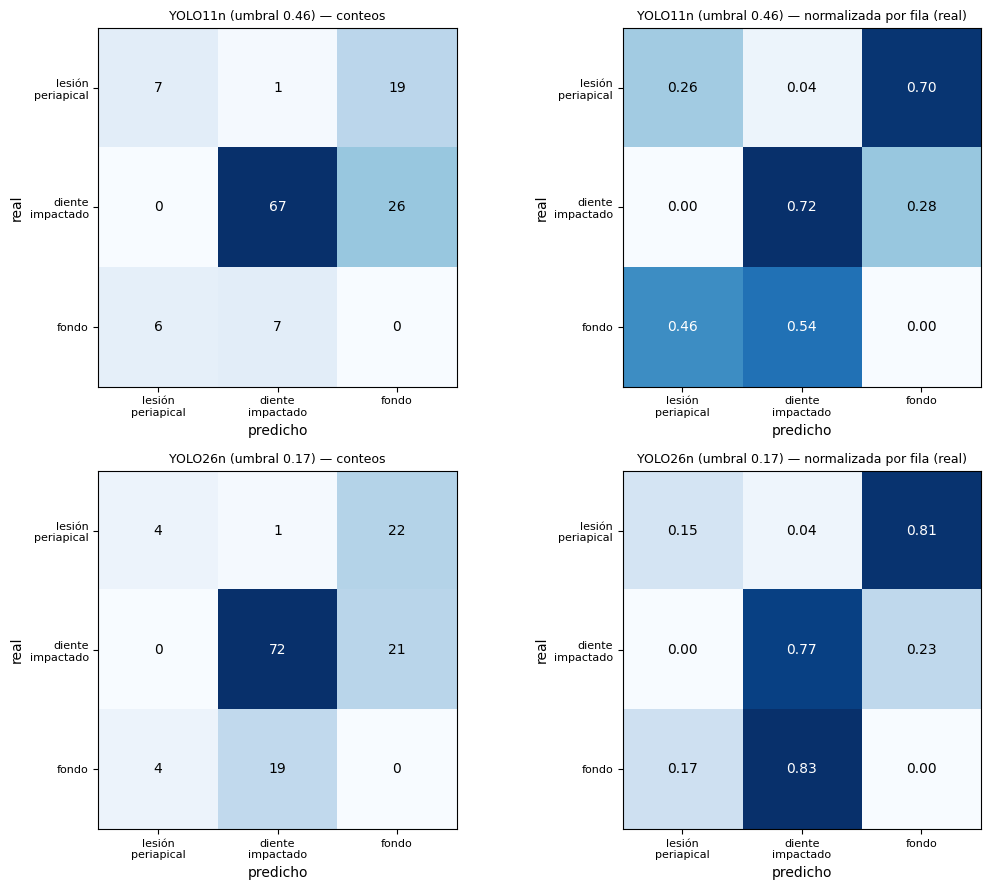

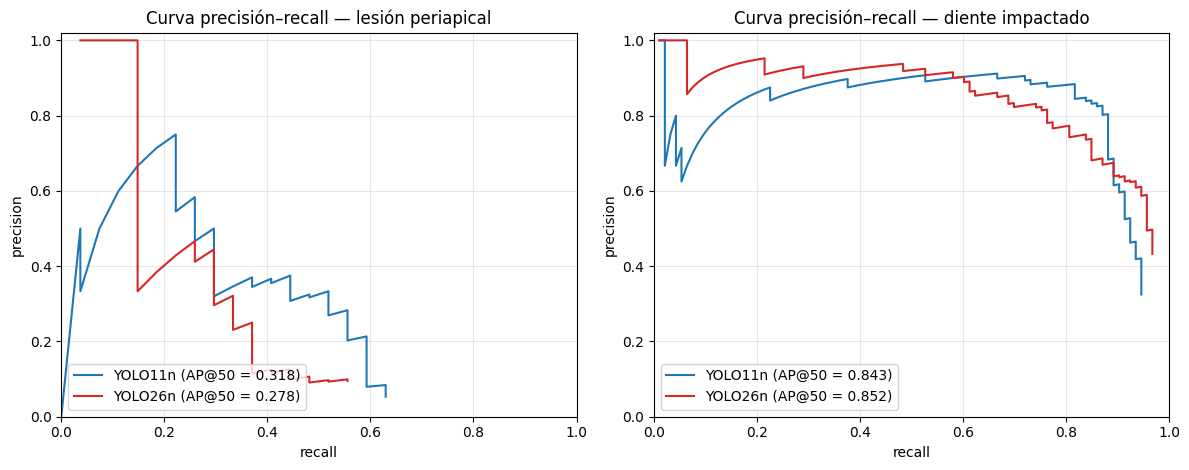

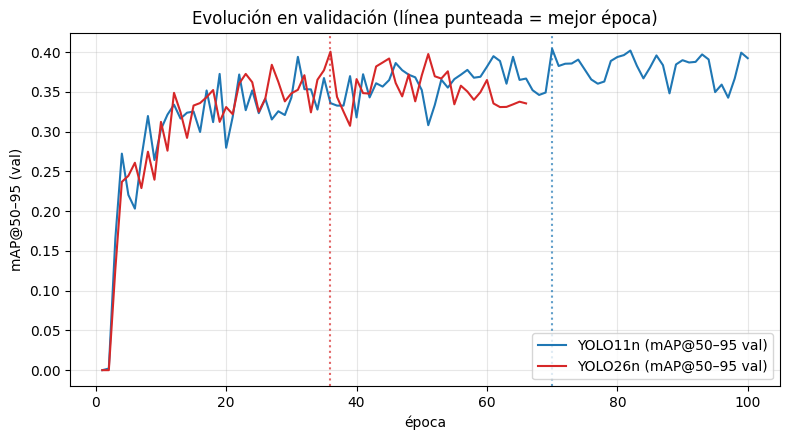

In [13]:
COLORS = {"yolo11n": "#1f77b4", "yolo26n": "#d62728"}
labs = ["lesión\nperiapical", "diente\nimpactado", "fondo"]

fig, axs = plt.subplots(2, 2, figsize=(11, 9))
CONF = {}
for r, n in enumerate(MODEL_NAMES):
    M = confusion(PRED[(n, PRIMARY_SEED, "test")], GTS["test"], TAU[(n, PRIMARY_SEED)]); CONF[n] = M
    for col, (mat, ttl) in enumerate([(M, "conteos"), (M / np.maximum(M.sum(1, keepdims=True), 1), "normalizada por fila (real)")]):
        ax = axs[r, col]; ax.imshow(mat, cmap="Blues")
        for i in range(3):
            for j in range(3):
                ax.text(j, i, f"{mat[i, j]:.2f}" if col else int(mat[i, j]), ha="center", va="center",
                        color="white" if mat[i, j] > mat.max() * .6 else "black")
        ax.set_xticks(range(3)); ax.set_xticklabels(labs, fontsize=8); ax.set_yticks(range(3)); ax.set_yticklabels(labs, fontsize=8)
        ax.set_xlabel("predicho"); ax.set_ylabel("real")
        ax.set_title(f"{LABEL[n]} (umbral {TAU[(n, PRIMARY_SEED)]:.2f}) — {ttl}", fontsize=9)
plt.tight_layout(); fig.savefig(RESULTS_DIR / "matriz_confusion_test.png", dpi=150); plt.show()
pd.concat({LABEL[n]: pd.DataFrame(CONF[n], index=["real_perio", "real_impact", "real_fondo"],
           columns=["pred_perio", "pred_impact", "pred_fondo"]) for n in MODEL_NAMES}).to_csv(RESULTS_DIR / "matriz_confusion_test.csv")

# ---- Curvas PR (IoU 0.5) por clase ----
fig, axs = plt.subplots(1, 2, figsize=(12, 4.8))
for c in (0, 1):
    for n in MODEL_NAMES:
        S = S_t[n]; conf = np.concatenate(S["conf"]); cls = np.concatenate(S["cls"]); tp0 = np.concatenate(S["tp"], axis=0)[:, 0]
        m = cls == c; o = np.argsort(-conf[m]); t = tp0[m][o].astype(float)
        tpc, fpc = np.cumsum(t), np.cumsum(1 - t); rec = tpc / S["gtc"][:, c].sum(); prec = tpc / (tpc + fpc)
        axs[c].plot(rec, prec, color=COLORS[n], label=f"{LABEL[n]} (AP@50 = {point[n]['AP50_c'][c]:.3f})")
    axs[c].set_title(f"Curva precisión–recall — {CLASS_ES[c]}"); axs[c].set_xlabel("recall"); axs[c].set_ylabel("precision")
    axs[c].set_xlim(0, 1); axs[c].set_ylim(0, 1.02); axs[c].grid(alpha=.3); axs[c].legend(loc="lower left")
plt.tight_layout(); fig.savefig(RESULTS_DIR / "curvas_PR_test.png", dpi=150); plt.show()

# ---- mAP de validación por época (de results.csv de cada entrenamiento) ----
fig, ax = plt.subplots(figsize=(8, 4.5))
for n in MODEL_NAMES:
    res = pd.read_csv(run_dir(n, PRIMARY_SEED) / "results.csv"); res.columns = [c.strip() for c in res.columns]
    ax.plot(res["epoch"], res["metrics/mAP50-95(B)"], color=COLORS[n], label=f"{LABEL[n]} (mAP@50–95 val)")
    be = SUMMARY[(n, PRIMARY_SEED)]["training"]["best_epoch"]; ax.axvline(be, color=COLORS[n], ls=":", alpha=.7)
ax.set_xlabel("época"); ax.set_ylabel("mAP@50–95 (val)"); ax.grid(alpha=.3); ax.legend()
ax.set_title("Evolución en validación (línea punteada = mejor época)")
plt.tight_layout(); fig.savefig(RESULTS_DIR / "curvas_val_mAP.png", dpi=150); plt.show()

## 12. Ejemplos de verdaderos positivos, falsos positivos y falsos negativos

Recortes alrededor de la caja de interés. **Amarillo punteado = anotación real**; color sólido = predicción del modelo con su confianza.

In [14]:
import cv2
COL = {0: (1.0, 0.25, 0.25), 1: (0.15, 0.8, 0.15)}

def panel(ax, img, focus, g, p, tau, title):
    x1, y1, x2, y2 = focus; cx, cy = (x1 + x2) / 2, (y1 + y2) / 2
    side = max(max(x2 - x1, y2 - y1) * 3.0, 500)
    X1, Y1 = int(max(0, cx - side / 2)), int(max(0, cy - side / 2))
    X2, Y2 = int(min(img.shape[1], cx + side / 2)), int(min(img.shape[0], cy + side / 2))
    ax.imshow(img[Y1:Y2, X1:X2], extent=(0, X2 - X1, Y2 - Y1, 0))
    inside = lambda b: not (b[2] < X1 or b[0] > X2 or b[3] < Y1 or b[1] > Y2)     # ¿la caja toca el recorte?
    for b in g["boxes"]:
        if inside(b):
            ax.add_patch(plt.Rectangle((b[0] - X1, b[1] - Y1), b[2] - b[0], b[3] - b[1], fill=False, ec="yellow", lw=1.6, ls="--"))
    for i in np.where(p["conf"] >= tau)[0]:
        b = p["boxes"][i]
        if not inside(b): continue                                                  # no dibujar cajas/etiquetas fuera del recorte
        c = COL[int(p["cls"][i])]
        ax.add_patch(plt.Rectangle((b[0] - X1, b[1] - Y1), b[2] - b[0], b[3] - b[1], fill=False, ec=c, lw=2.2))
        ax.text(min(max(b[0] - X1, 2), (X2 - X1) - 90), max(b[1] - Y1 - 6, 14), f"{CLASS_SHORT[int(p['cls'][i])]} {p['conf'][i]:.2f}",
                color="white", fontsize=8, clip_on=True, bbox=dict(facecolor=c, alpha=.85, pad=1, lw=0))
    ax.set_xlim(0, X2 - X1); ax.set_ylim(Y2 - Y1, 0); ax.set_title(title, fontsize=8.5); ax.axis("off")

def pick_examples(n):
    tau = TAU[(n, PRIMARY_SEED)]; TPs, FPs, FNs = [], [], []
    for i, (p, g) in enumerate(zip(PRED[(n, PRIMARY_SEED, "test")], GTS["test"])):
        tp, fp, fn = classify_detections(p, g, tau)
        TPs += [(float(p["conf"][a]), i, a, int(p["cls"][a])) for a, _ in tp]
        FPs += [(float(p["conf"][a]), i, a, int(p["cls"][a])) for a in fp]
        FNs += [(i, j, int(g["cls"][j])) for j in fn]
    sel = []
    for c in (0, 1):
        t = [x for x in TPs if x[3] == c]
        if t: x = max(t); sel.append(("Verdadero positivo", x[1], PRED[(n, PRIMARY_SEED, "test")][x[1]]["boxes"][x[2]], x[3]))
    seen_img, nfp = set(), 0
    for x in sorted(FPs, reverse=True):                      # los 2 FP más confiados, de imágenes distintas
        if x[1] in seen_img: continue
        seen_img.add(x[1]); nfp += 1
        sel.append(("Falso positivo", x[1], PRED[(n, PRIMARY_SEED, "test")][x[1]]["boxes"][x[2]], x[3]))
        if nfp == 2: break
    for c in (0, 1):
        f = [x for x in FNs if x[2] == c]
        if f: x = f[0]; sel.append(("Falso negativo", x[0], GTS["test"][x[0]]["boxes"][x[1]], c))
    return sel

for n in MODEL_NAMES:
    sel = pick_examples(n); fig, axs = plt.subplots(2, 3, figsize=(15, 10.5), constrained_layout=True)
    for ax in axs.ravel(): ax.axis("off")
    for ax, (kind, i, focus, c) in zip(axs.ravel(), sel):
        it = ITEMS["test"][i]
        img = cv2.cvtColor(cv2.imread(str(it["path"])), cv2.COLOR_BGR2RGB)
        panel(ax, img, focus, GTS["test"][i], PRED[(n, PRIMARY_SEED, "test")][i], TAU[(n, PRIMARY_SEED)], f"{kind} · {CLASS_ES[c]} · {it['name']}")
    fig.suptitle(f"{LABEL[n]} — ejemplos en test (umbral {TAU[(n, PRIMARY_SEED)]:.2f})", fontsize=12)
    fig.savefig(RESULTS_DIR / f"ejemplos_TP_FP_FN_{n}.png", dpi=130); plt.show()

Output hidden; open in https://colab.research.google.com to view.

## 13. Complejidad del modelo (mismo método para ambos)

Se reporta **sin fusionar** (modelo de entrenamiento) y **fusionado** (modelo de inferencia, el relevante para el despliegue), siempre a `imgsz=1024`. Como control, los parámetros fusionados deben ser ≈ 2,582,542 (YOLO11n) y ≈ 2,375,226 (YOLO26n), los valores que Ultralytics imprimió al validar. En YOLO26 la cabeza de inferencia *end-to-end* difiere de la de entrenamiento, por eso conviene citar la versión fusionada.

In [15]:
from ultralytics.utils.torch_utils import get_flops

def complexity_of(m):                      # parámetros y GFLOPs calculados igual para ambos (m.info() devuelve None en esta versión)
    return int(sum(p.numel() for p in m.model.parameters())), float(get_flops(m.model, imgsz=IMGSZ))

rows = []
for n in MODEL_NAMES:
    m = YOLO(str(best_path(n, PRIMARY_SEED)))
    p0, g0 = complexity_of(m)              # modelo de entrenamiento
    m.fuse()
    p1, g1 = complexity_of(m)              # modelo fusionado (inferencia)
    rows.append({"modelo": LABEL[n], "params_sin_fusionar": p0, "GFLOPs_sin_fusionar": round(g0, 2),
                 "params_fusionado": p1, "GFLOPs_fusionado": round(g1, 2),
                 "tamano_best_pt_MB": round(best_path(n, PRIMARY_SEED).stat().st_size / 1e6, 2), "imgsz": IMGSZ})
    del m
COMPLEXITY = pd.DataFrame(rows); display(COMPLEXITY)
COMPLEXITY.to_csv(RESULTS_DIR / "tabla_complejidad.csv", index=False)

YOLO11n summary (fused): 101 layers, 2,582,542 parameters, 0 gradients, 6.4 GFLOPs
YOLO26n summary (fused): 122 layers, 2,375,226 parameters, 0 gradients, 5.3 GFLOPs


,modelo,params_sin_fusionar,GFLOPs_sin_fusionar,params_fusionado,GFLOPs_fusionado,tamano_best_pt_MB,imgsz
0,YOLO11n,2590230,16.89,2582542,16.56,5.51,1024
1,YOLO26n,2504580,15.58,2375226,14.09,5.42,1024


## 14. Tiempo de inferencia por imagen (T4, misma sesión, rondas alternadas)

- Lote = 1, `imgsz=1024`, imagen original en memoria (incluye letterbox en el preprocesamiento).
- Calentamiento de 20 imágenes por modelo; luego 3 rondas sobre las 106 imágenes de test **alternando el orden** de los modelos.
- Se usa el umbral operativo de cada modelo (el que se usaría en el prototipo).
- Tiempos que reporta Ultralytics con sincronización de CUDA: preprocesamiento, inferencia y postprocesamiento.

In [16]:
imgs = [cv2.imread(str(it["path"])) for it in ITEMS["test"]]          # BGR, como espera Ultralytics
models = {n: YOLO(str(best_path(n, PRIMARY_SEED))) for n in MODEL_NAMES}
ROUNDS, WARM = 3, 20

def run_pass(n):
    out = []
    for im in imgs:
        r = models[n].predict(im, imgsz=IMGSZ, conf=TAU[(n, PRIMARY_SEED)], verbose=False, device=0)[0]
        out.append({**r.speed, "n_det": len(r.boxes)})
    return out

for n in MODEL_NAMES:
    for im in imgs[:WARM]: models[n].predict(im, imgsz=IMGSZ, conf=TAU[(n, PRIMARY_SEED)], verbose=False, device=0)

rec = []
for rd in range(ROUNDS):
    order = MODEL_NAMES if rd % 2 == 0 else MODEL_NAMES[::-1]
    for n in order:
        for row in run_pass(n): rec.append({"modelo": LABEL[n], "ronda": rd, **row})
T = pd.DataFrame(rec); T["total_ms"] = T["preprocess"] + T["inference"] + T["postprocess"]

def summ(x):
    return pd.Series({"media": x.mean(), "mediana": x.median(), "DE": x.std(), "P95": x.quantile(.95)})
TIMING = T.groupby("modelo")[["preprocess", "inference", "postprocess", "total_ms"]].apply(
    lambda d: pd.concat({c: summ(d[c]) for c in d.columns})).unstack(0).round(2)
display(T.groupby("modelo")[["preprocess", "inference", "postprocess", "total_ms"]].agg(["mean", "median", "std"]).round(2))
fps = (1000 / T.groupby("modelo")["total_ms"].mean()).round(1); print("FPS (1000 / media total):", fps.to_dict())
print("Media por ronda (total_ms) — comprobar que no hay deriva:")
display(T.groupby(["modelo", "ronda"])["total_ms"].mean().unstack().round(2))
T.to_csv(RESULTS_DIR / "tiempos_inferencia_crudos.csv", index=False)
T.groupby("modelo")[["preprocess", "inference", "postprocess", "total_ms"]].agg(["mean", "median", "std"]).round(3).to_csv(RESULTS_DIR / "tabla_tiempos.csv")
del models; torch.cuda.empty_cache()

preprocess              inference              postprocess         \
              mean median   std      mean median   std        mean median   
modelo                                                                      
YOLO11n       4.41   4.09  0.93      9.09   8.23  2.23        0.86   0.69   
YOLO26n       4.09   4.00  0.50      9.92   9.66  1.27        0.34   0.34   

              total_ms               
          std     mean median   std  
modelo                               
YOLO11n  0.37    14.36  13.12  3.19  
YOLO26n  0.07    14.35  14.02  1.64

FPS (1000 / media total): {'YOLO11n': 69.6, 'YOLO26n': 69.7}
Media por ronda (total_ms) — comprobar que no hay deriva:


ronda,0,1,2
modelo,,,
YOLO11n,16.32,13.56,13.22
YOLO26n,14.50,14.31,14.24


> En el artículo: reportar la GPU (Tesla T4), `imgsz`, lote 1, nº de imágenes y rondas, y que **incluye** pre y postprocesamiento. YOLO26 es *NMS-free*, así que su postprocesamiento suele ser menor.

## 15. Falsos positivos en radiografías sin patología (relevante para el prototipo)

In [17]:
rows = []
neg = [i for i, g in enumerate(GTS["test"]) if len(g["cls"]) == 0]
for n in MODEL_NAMES:
    tau = TAU[(n, PRIMARY_SEED)]; P = PRED[(n, PRIMARY_SEED, "test")]
    k = np.array([(P[i]["conf"] >= tau).sum() for i in neg])
    lo, hi = ci([np.mean((np.random.default_rng(b).choice(k, len(k)) > 0)) for b in range(B_BOOT)])
    rows.append({"modelo": LABEL[n], "imagenes_negativas": len(neg), "con_algun_FP": int((k > 0).sum()),
                 "fraccion_con_FP [IC95]": f"{(k > 0).mean():.3f} [{lo:.3f}–{hi:.3f}]", "FP_medios_por_imagen": round(k.mean(), 3)})
NEG = pd.DataFrame(rows); display(NEG); NEG.to_csv(RESULTS_DIR / "tabla_negativas.csv", index=False)

,modelo,imagenes_negativas,con_algun_FP,fraccion_con_FP [IC95],FP_medios_por_imagen
0,YOLO11n,57,5,0.088 [0.018–0.158],0.140
1,YOLO26n,57,4,0.070 [0.018–0.140],0.123


## 16. Exportar evidencia

In [18]:
evidence_out = {
    "created": datetime.now().isoformat(), "versions": VERSIONS, "gpu": GPU,
    "primary_seed": PRIMARY_SEED, "seeds": SEEDS, "bootstrap_B": B_BOOT, "imgsz": IMGSZ,
    "threshold_policy": "umbral que maximiza F1 global en val, fijo en test",
    "thresholds": {f"{n}_seed{s}": TAU[(n, s)] for n in MODEL_NAMES for s in SEEDS},
    "protocol_hash": SUMMARY[(MODEL_NAMES[0], PRIMARY_SEED)]["protocol_hash"],
    "dataset_fingerprint": DATASET_FINGERPRINT, "data_yaml_sha256": yaml_hash, "split_list_sha256": split_hashes,
    "best_pt_sha256": {f"{n}_seed{s}": sha(best_path(n, s).read_bytes()) for n in MODEL_NAMES for s in SEEDS},
}
(RESULTS_DIR / "evidencia_comparacion.json").write_text(json.dumps(evidence_out, indent=2))
print(json.dumps(evidence_out, indent=2))
print("\nArchivos en:", RESULTS_DIR); print(sorted(p.name for p in RESULTS_DIR.iterdir() if p.is_file()))

{
  "created": "2026-10-08T05:19:17.514716",
  "versions": {
    "python": "3.13.15",
    "ultralytics": "8.4.118",
    "torch": "2.11.0+cu130",
    "cuda": "13.0",
    "gpu": "Tesla T4"
  },
  "gpu": "Tesla T4",
  "primary_seed": 42,
  "seeds": [
    42
  ],
  "bootstrap_B": 1000,
  "imgsz": 1024,
  "threshold_policy": "umbral que maximiza F1 global en val, fijo en test",
  "thresholds": {
    "yolo11n_seed42": 0.46,
    "yolo26n_seed42": 0.17
  },
  "protocol_hash": "22fbafd193da7772e49e7a7f171a1264d03484fd0c3de4f432ad2902fae08324",
  "dataset_fingerprint": "135b5931ce984659dd046d2fc50774fa87eb6c6cbb018896bfbd3f127026a51b",
  "data_yaml_sha256": "1621825915e761895e379b67ec63ed25f6c75e4e608b5d29a64db75d73a625b1",
  "split_list_sha256": {
    "train": "5c2f945aea48c55fa4db3a14d1e6e5053598ba5ded4587c0200c02334dbe3d36",
    "val": "d79395131d954e0879e73ba3dfb06f4b33ae582febe20154591d579c31f9446c",
    "test": "9a8f58210b497e25b9198e6070890c2a9292f2e86ea3635645eb54a585f499a1"
  },
  "best

---

### Checklist al terminar

- [ ] La celda 6 no abortó (mAP propio ≈ Ultralytics).
- [ ] Tablas: `tabla_global_test.csv`, `tabla_por_clase_test.csv`, `tabla_complejidad.csv`, `tabla_tiempos.csv`, `tabla_negativas.csv`.
- [ ] Figuras: `matriz_confusion_test.png`, `curvas_PR_test.png`, `curvas_val_mAP.png`, `ejemplos_TP_FP_FN_*.png`.
- [ ] `evidencia_comparacion.json` con los SHA-256 de `best.pt`, split y dataset.
- [ ] Subir todo a `resultados/` del repositorio de GitHub.

### Notas para el artículo

- Reportar las métricas con IC 95 % y la diferencia pareada; evitar frases como "YOLO26n supera a YOLO11n" si el IC de Δ incluye 0.
- Aclarar que precision, recall y F1 se calcularon con el umbral elegido en validación.
- Citar el número de instancias por clase en test (27 periapicales, 93 impactados): el IC de la clase periapical será amplio.
- Es una evaluación de **concordancia algorítmica** con las anotaciones de DENTEX, no validación clínica.